In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
import pandas as pd
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
Cards = pd.read_csv("./data/cards_data.csv")
Transactions = pd.read_csv("./data/transactions_data.csv")
Users = pd.read_csv("./data/users_data.csv")

In [3]:
Cards['credit_limit'] = Cards['credit_limit'].replace('[\$,]', '', regex=True).astype(float)
Users['yearly_income'] = Users['yearly_income'].replace('[\$,]', '', regex=True).astype(float)
Users['total_debt'] = Users['total_debt'].replace('[\$,]', '', regex=True).astype(float)
Users['per_capita_income'] = Users['per_capita_income'].replace('[\$,]', '', regex=True).astype(float)
Transactions['amount'] = Transactions['amount'].replace('[\$,]', '', regex=True).astype(float)

# 合併三表
Trans_merge = pd.DataFrame()
Trans_merge = Transactions.merge(Cards, left_on="card_id", right_on="id", suffixes=("_txn","_card"))
Trans_merge = Trans_merge.merge(Users, left_on="client_id_txn", right_on="id", suffixes=("","_user"))

In [8]:
from sklearn.preprocessing import RobustScaler
from geopy.distance import geodesic
import numpy as np
import pandas as pd

df = Trans_merge.copy()

# 指定群組欄位
GROUP_BY_CLIENT = ['client_id_txn']

# 確保日期欄位為 datetime 格式
df['date'] = pd.to_datetime(df['date'])

# 比率 Ratio
## 1. 交易金額佔信用額度的比率 (Txn_Amount / Credit_Limit)
df['Risk_Amount_to_Limit'] = np.where(
    df['credit_limit'].gt(0),
    df['amount'] / df['credit_limit'],
    np.nan
)

## 2. 總負債佔年收入的比率 (Total_Debt / Yearly_Income)
df['Risk_Debt_to_Income'] = np.where(
    df['yearly_income'].gt(0),
    df['total_debt'] / df['yearly_income'],
    np.nan
)

## 3. 信用額度使用壓力 (Total_Debt / Credit_Limit)
df['Risk_Debt_to_Limit'] = np.where(
    df['credit_limit'].gt(0),
    df['total_debt'] / df['credit_limit'],
    np.nan
)

## 4. 小時交易量佔信用評分的比率 (Hourly_Volume / Credit_Score)
if 'hourly_transaction_volume' in df.columns:
    df['Risk_Volume_to_Score'] = np.where(
        df['credit_score'].gt(0),
        df['hourly_transaction_volume'] / df['credit_score'],
        np.nan
    )
else:
    df['Risk_Volume_to_Score'] = np.nan

## 5. 年收入佔當地人均收入比率 (Yearly_Income / Per_Capita_Income)
df['Risk_Income_vs_Local'] = np.where(
    df['per_capita_income'].gt(0),
    df['yearly_income'] / df['per_capita_income'],
    np.nan
)

## 6. 信用評分正規化 (Robust Standardization is recommended by the paper) [4]
scaler = RobustScaler()
df['credit_score_scaled'] = scaler.fit_transform(df[['credit_score']])

# 7. 交易頻率比率 (Transaction Velocity)
for days in [4, 7]:
    col_name = f'Txn_Count_{days}D'
    df[col_name] = (
        df.groupby(GROUP_BY_CLIENT, group_keys=False)
        .apply(lambda g: g.assign(
            **{
                col_name: g.sort_values('date')
                .set_index('date')['id_txn']
                .rolling(f'{days}D', closed='left')
                .count()
                .reset_index(drop=True)
            }
        ))[col_name]
    )

df['Ratio_Txn_Count_vs_7D_Avg_4D'] = np.where(
    df['Txn_Count_7D'].gt(0),
    df['Txn_Count_4D'] / df['Txn_Count_7D'],
    np.nan
)

# 8. 金額偏差比率 (Amount Deviation Ratios)
for days in [6, 7]:
    mean_col = f'Amount_Mean_{days}D'
    std_col = f'Amount_Std_{days}D'

    df = df.groupby(GROUP_BY_CLIENT, group_keys=False).apply(
        lambda g: g.assign(
            **{
                mean_col: g.sort_values('date')
                .set_index('date')['amount']
                .rolling(f'{days}D', closed='left')
                .mean()
                .reset_index(drop=True),
                std_col: g.sort_values('date')
                .set_index('date')['amount']
                .rolling(f'{days}D', closed='left')
                .std()
                .reset_index(drop=True)
            }
        )
    )

    df[f'Ratio_Amount_vs_Mean_{days}D'] = np.where(
        df[mean_col].gt(0),
        df['amount'] / df[mean_col],
        np.nan
    )

    df[f'Z_Score_Amount_{days}D'] = np.where(
        df[std_col].gt(0),
        (df['amount'] - df[mean_col]) / df[std_col],
        np.nan
    )
    
# Boolean
## 1. 是否為線上交易 (One-Hot Encoding of key transaction type)
df['is_chip_txn'] = (df['use_chip'] == 'Chip Transaction').astype(int)
df['is_swipe_txn'] = (df['use_chip'] == 'Swipe Transaction').astype(int)
df['is_online_txn'] = (df['use_chip'] == 'Online').astype(int)

## 2. 卡片是否已在暗網 (Binary/Boolean encoding)
df['card_on_dark_web_encoded'] = (df['card_on_dark_web'] == 'Yes').astype(int)
df['is_credit_card'] = (df['card_type'] == 'Credit').astype(int)

In [13]:
df_clean = df.dropna(subset=['id_txn']).copy()
with open('./data/train_fraud_labels.json', 'r') as f:
    fraud_data = json.load(f)

fraud_dict = fraud_data['target']
fraud_dict = {int(k): v for k, v in fraud_dict.items()}

df_clean['id_txn'] = df_clean['id_txn'].astype(int)
df_clean['is_fraud'] = df_clean['id_txn'].map(fraud_dict)
df_clean = df_clean[df_clean['is_fraud'].notna()].copy()
df_clean['is_fraud'] = df_clean['is_fraud'].astype(str).str.lower().map({
    'yes': True,
    'no': False,
})

new_cols = [c for c in df.columns if c not in Trans_merge]

print(new_cols)
print("\n")
print(df[new_cols].head())

['Risk_Amount_to_Limit', 'Risk_Debt_to_Income', 'Risk_Debt_to_Limit', 'Risk_Volume_to_Score', 'Risk_Income_vs_Local', 'credit_score_scaled', 'Txn_Count_4D', 'Txn_Count_7D', 'Ratio_Txn_Count_vs_7D_Avg_4D', 'Amount_Mean_6D', 'Amount_Std_6D', 'Ratio_Amount_vs_Mean_6D', 'Z_Score_Amount_6D', 'Amount_Mean_7D', 'Amount_Std_7D', 'Ratio_Amount_vs_Mean_7D', 'Z_Score_Amount_7D', 'is_chip_txn', 'is_swipe_txn', 'is_online_txn', 'card_on_dark_web_encoded', 'is_credit_card']


   Risk_Amount_to_Limit  Risk_Debt_to_Income  Risk_Debt_to_Limit  \
0             -1.400000             2.281687         2002.781818   
1              0.001601             3.042873           12.322967   
2              0.005405             1.060698            2.468585   
3              0.005314             2.411921            3.419142   
4              0.002428             1.406951            5.032282   

   Risk_Volume_to_Score  Risk_Income_vs_Local  credit_score_scaled  \
0                   NaN              2.038811         

In [29]:
features = [
    'Risk_Amount_to_Limit',
    'Risk_Debt_to_Income',
    'Risk_Debt_to_Limit',
    # 'Risk_Volume_to_Score',
    'Risk_Income_vs_Local',
    'credit_score_scaled',
    'Txn_Count_4D',
    'Txn_Count_7D',
    'Ratio_Txn_Count_vs_7D_Avg_4D',
    'Ratio_Amount_vs_Mean_6D',
    'Ratio_Amount_vs_Mean_7D',
    'Z_Score_Amount_6D',
    'Z_Score_Amount_7D',
    'is_chip_txn',
    'is_swipe_txn',
    'is_online_txn',
    'card_on_dark_web_encoded',
    'is_credit_card'
]

print("候選特徵清單：")
for f in features:
    print(f"- {f}")

df_selected = df_clean[features + ['is_fraud']].dropna()

候選特徵清單：
- Risk_Amount_to_Limit
- Risk_Debt_to_Income
- Risk_Debt_to_Limit
- Risk_Income_vs_Local
- credit_score_scaled
- Txn_Count_4D
- Txn_Count_7D
- Ratio_Txn_Count_vs_7D_Avg_4D
- Ratio_Amount_vs_Mean_6D
- Ratio_Amount_vs_Mean_7D
- Z_Score_Amount_6D
- Z_Score_Amount_7D
- is_chip_txn
- is_swipe_txn
- is_online_txn
- card_on_dark_web_encoded
- is_credit_card


XGBoost 特徵重要性：
Txn_Count_7D                    0.263925
Risk_Debt_to_Income             0.224646
Risk_Debt_to_Limit              0.201808
credit_score_scaled             0.073328
Risk_Income_vs_Local            0.066990
Ratio_Amount_vs_Mean_6D         0.033049
Ratio_Amount_vs_Mean_7D         0.028522
Ratio_Txn_Count_vs_7D_Avg_4D    0.027467
Z_Score_Amount_7D               0.023851
Z_Score_Amount_6D               0.023238
dtype: float32


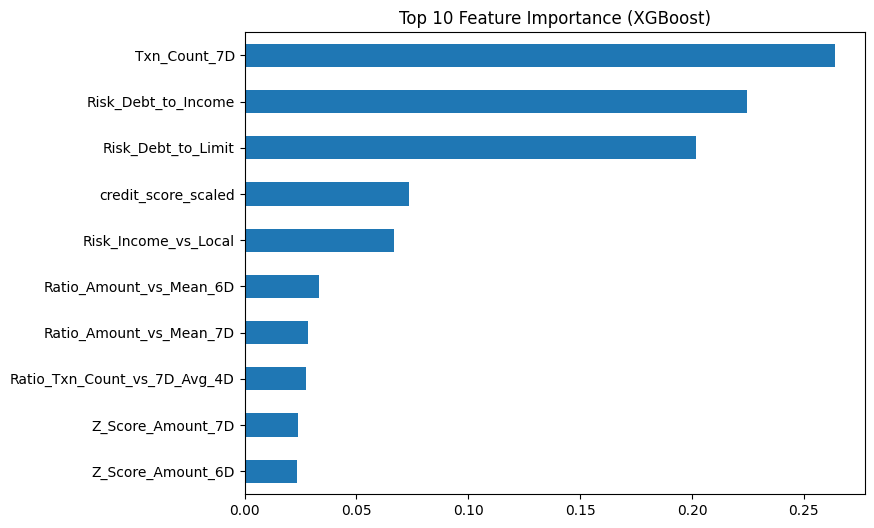

In [26]:
from xgboost import XGBClassifier

X = df_selected[features]
y = df_selected['is_fraud']

xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X, y)

# 特徵重要性
importance = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print("XGBoost 特徵重要性：")
print(importance.head(10))

# 繪圖
plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

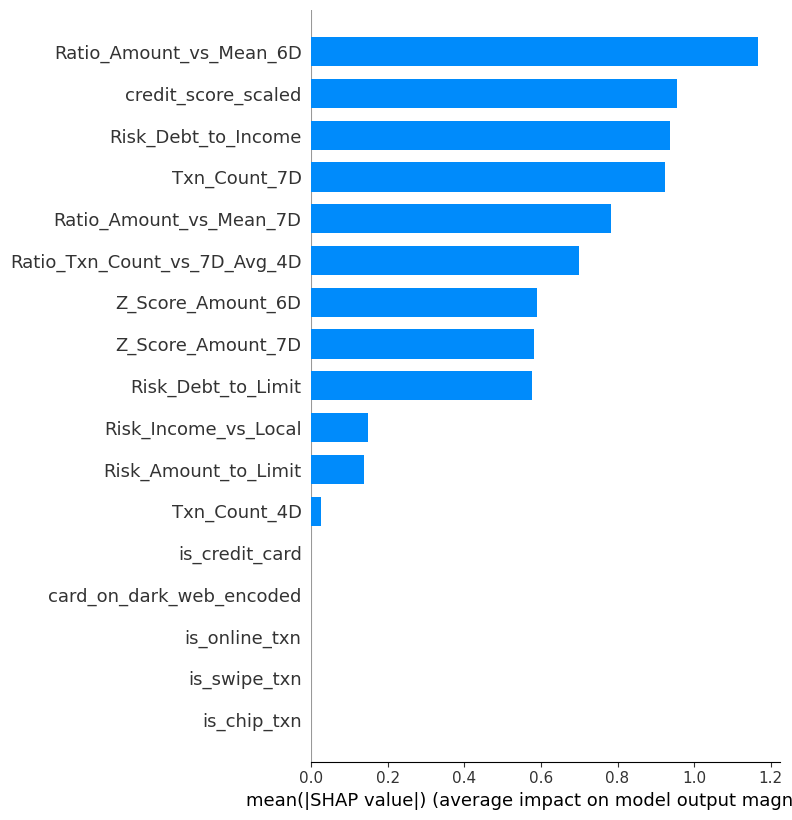

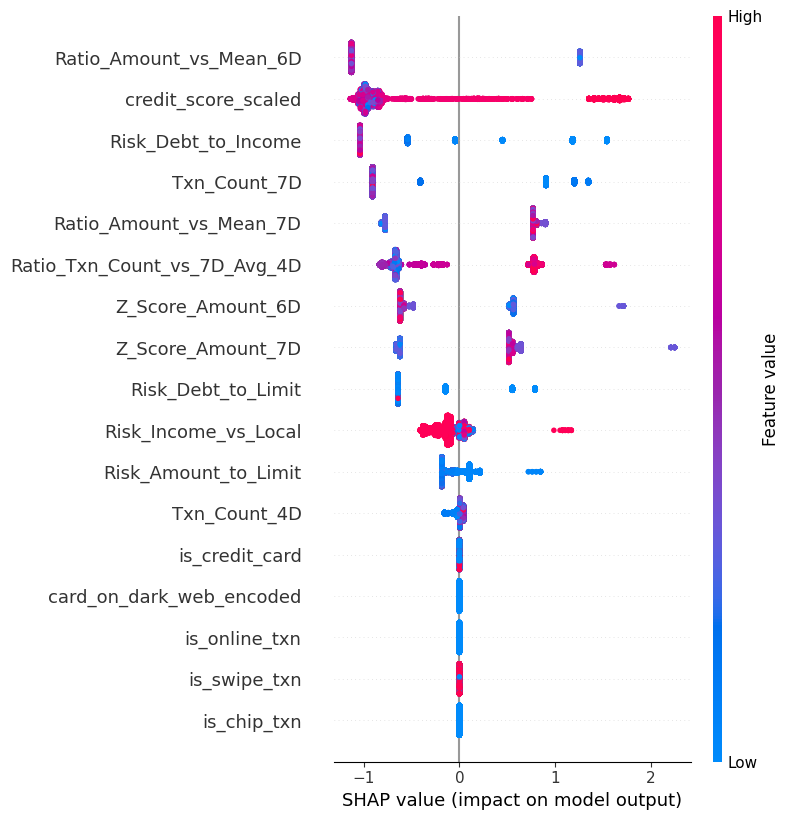

In [28]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

# summary plot
shap.summary_plot(shap_values, X, plot_type="bar")

# detailed summary (dot plot)
shap.summary_plot(shap_values, X)